# 04 — XGBoost Model Analysis

Post-hoc analysis of the XGBoost credit-scoring baseline, built as the structured
counterpart to the LLM analysis notebooks (`01g`, `02d`). Same lens on both sides
so the final presentation can compare them on equal footing.

Covers the brief's required axes for the ML model: **performance, calibration,
SHAP explainability, feature reliance, and error analysis.**

- Runs on the shared **`tuning_sample`** (the same 100 loans the LLM phases use),
  so feature reliance and errors are directly comparable across model families.
- **No retraining and no API calls** — loads `models/xgb_model.joblib` and the
  saved scaler / feature columns.
- **`test_batch` is never touched here** — that is reserved for `04b` only.


In [1]:
import sys; sys.path.insert(0, '../llm_models')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from llm_utils import run_ml_on_sample, load_llm_sample, LLM_FEATURES, FEATURE_DESCRIPTIONS

DATA_DIR    = '../../data/processed'
MODEL_DIR   = '../../models'
RESULTS_ML  = '../../data/results/ml'

# ── Load model artifacts ────────────────────────────────────────────────────
scaler       = joblib.load(f'{DATA_DIR}/02_scaler.joblib')
feature_cols = joblib.load(f'{DATA_DIR}/02_feature_columns.joblib')
model        = joblib.load(f'{MODEL_DIR}/xgb_model.joblib')
threshold    = joblib.load(f'{MODEL_DIR}/thresholds.joblib')['xgb']

# ── Load the shared sample ──────────────────────────────────────────────────
sample  = load_llm_sample()
y_true  = sample['loan_status'].values          # 1 = Fully Paid, 0 = Charged Off

# ── Re-encode exactly as run_ml_on_sample / 02_Preprocessing does, but keep the
#    encoded design matrix so we can run SHAP on it. ──────────────────────────
def encode_for_model(df):
    df = df.copy()
    if not pd.api.types.is_numeric_dtype(df['term']):
        df['term'] = df['term'].map({' 36 months': 36, ' 60 months': 60})
    if 'emp_length' in df and not pd.api.types.is_numeric_dtype(df['emp_length']):
        df['emp_length'] = df['emp_length'].map({
            '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
            '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
            '10+ years': 10})
    if 'mths_since_last_delinq' in df:
        df['has_past_delinq'] = df['mths_since_last_delinq'].notna().astype(int)
        df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)
    if 'issue_d' in df and 'earliest_cr_line' in df:
        df['credit_history_years'] = (pd.to_datetime(df['issue_d']) -
                                      pd.to_datetime(df['earliest_cr_line'])).dt.days / 365.25
    df.drop(columns=['grade', 'zip_code', 'addr_state', 'issue_d',
                     'earliest_cr_line', 'desc'], errors='ignore', inplace=True)
    df = pd.get_dummies(df, columns=['sub_grade', 'verification_status', 'purpose',
                                     'initial_list_status', 'application_type',
                                     'home_ownership'])
    X = df.drop(columns=['loan_status'], errors='ignore').reindex(columns=feature_cols, fill_value=0)
    return X

X_enc    = encode_for_model(sample)               # unscaled, for SHAP display colouring
X_scaled = scaler.transform(X_enc).astype(np.float32)

probs, preds = run_ml_on_sample(sample)
print(f'Loaded XGBoost. Sample={len(sample)} loans | default rate (Charged Off) = {1-y_true.mean():.2f}')
print(f'Decision threshold (P[Fully Paid] >= t): {threshold:.3f}')


Loaded XGBoost. Sample=100 loans | default rate (Charged Off) = 0.15
Decision threshold (P[Fully Paid] >= t): 0.476


## Part 1 — Performance

Headline metrics on the tuning sample. `Charged Off` is the minority/positive-risk
class, so precision / recall / F1 on **Charged Off** are what matter, not accuracy.

,accuracy,auc,precision_charged_off,recall_charged_off,f1_charged_off
XGBoost,0.65,0.671,0.206,0.467,0.286



Saved 03_model_performance.csv:


,model,roc_auc_test,accuracy_test,precision_co,recall_co,f1_co,threshold
0,Logistic Regression,0.707500,0.684631,0.290595,0.592529,0.389947,0.466353
1,XGBoost,0.712230,0.676834,0.289485,0.618668,0.394416,0.476263
2,ANN,0.708769,0.679010,0.288178,0.603374,0.390059,0.456472


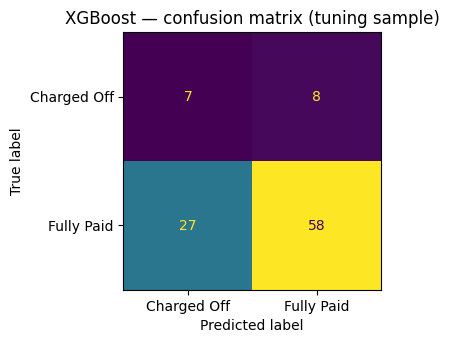

In [2]:
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Charged Off = 0 is the risk class. Build a CO-positive view for P/R/F1.
co_true = (y_true == 0).astype(int)
co_pred = (preds  == 0).astype(int)

perf = {
    'accuracy':            accuracy_score(y_true, preds),
    'auc':                 roc_auc_score(y_true, probs),
    'precision_charged_off': precision_score(co_true, co_pred, zero_division=0),
    'recall_charged_off':    recall_score(co_true, co_pred, zero_division=0),
    'f1_charged_off':        f1_score(co_true, co_pred, zero_division=0),
}
perf_df = pd.DataFrame([perf], index=['XGBoost']).round(3)
display(perf_df)

# Reference: the saved cross-model performance table (LR / XGB / ANN).
try:
    saved = pd.read_csv(f'{RESULTS_ML}/03_model_performance.csv')
    print('\nSaved 03_model_performance.csv:'); display(saved)
except FileNotFoundError:
    print('03_model_performance.csv not found.')

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true, preds),
                       display_labels=['Charged Off', 'Fully Paid']).plot(ax=ax, colorbar=False)
ax.set_title('XGBoost — confusion matrix (tuning sample)'); plt.tight_layout(); plt.show()


## Part 2 — Calibration

Unlike the LLMs (whose token-probabilities saturate near 1.0, see `01e`), XGBoost
emits a genuine probability. This is the **"scorer vs classifier"** contrast for the
deck: we measure how trustworthy that probability is with a reliability curve,
**Brier score**, and **ECE** (same metrics as `01e`).

Brier score: 0.219   (lower is better)
ECE (10-bin): 0.296   (lower is better)


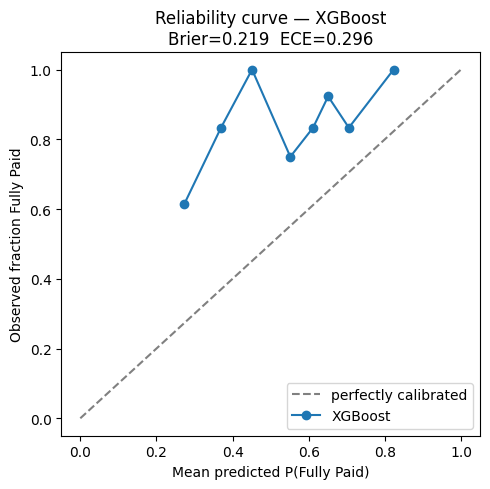

In [3]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# probs = P(Fully Paid). Calibrate against the Fully-Paid label.
brier = brier_score_loss(y_true, probs)

def expected_calibration_error(y, p, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(p, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0: continue
        ece += (m.sum() / len(p)) * abs(y[m].mean() - p[m].mean())
    return ece

ece = expected_calibration_error(y_true, probs)
print(f'Brier score: {brier:.3f}   (lower is better)')
print(f'ECE (10-bin): {ece:.3f}   (lower is better)')

frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=8, strategy='quantile')
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfectly calibrated')
ax.plot(mean_pred, frac_pos, 'o-', label='XGBoost')
ax.set_xlabel('Mean predicted P(Fully Paid)'); ax.set_ylabel('Observed fraction Fully Paid')
ax.set_title(f'Reliability curve — XGBoost\nBrier={brier:.3f}  ECE={ece:.3f}')
ax.legend(); plt.tight_layout(); plt.show()


## Part 3 — SHAP Explainability

The brief's required ML explainability artifact. SHAP attributes each prediction to
its features. We show the global view (beeswarm + bar), aggregate importance back to
the **30 source features** (the model is trained on one-hot columns), and a couple of
local explanations.

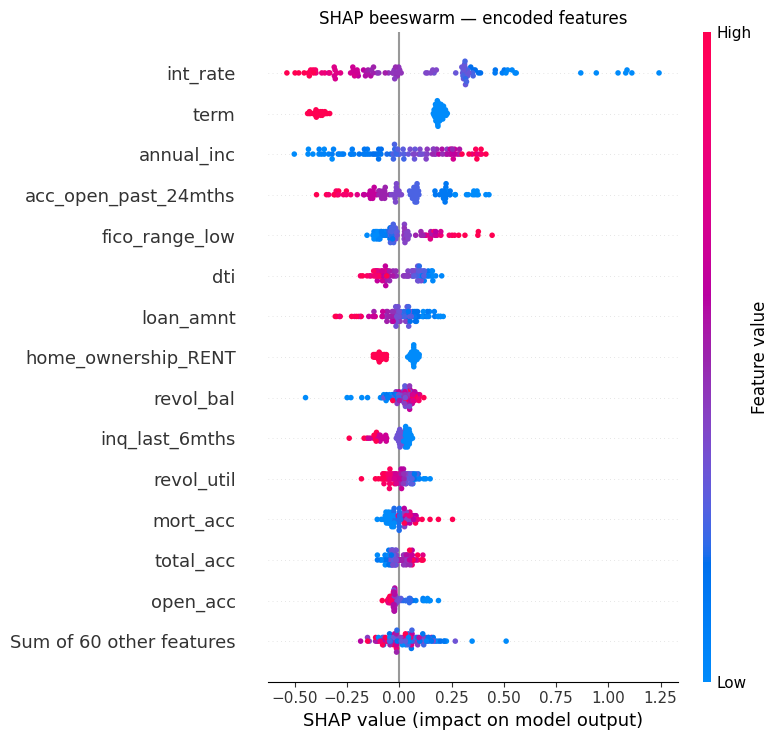

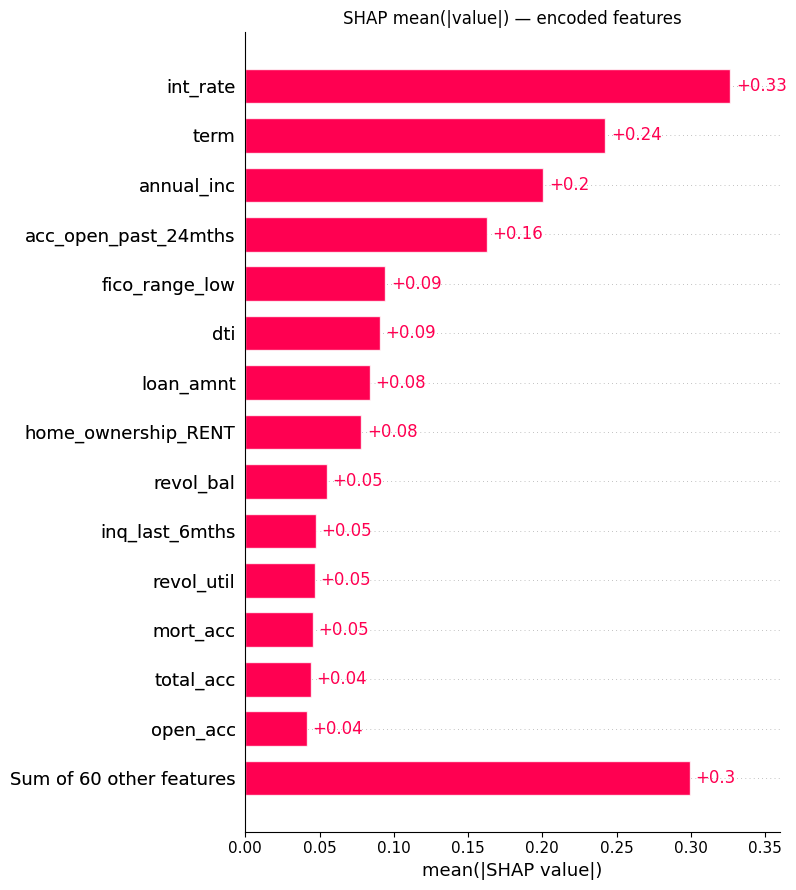

In [4]:
import shap

explainer = shap.TreeExplainer(model)
sv = explainer(X_scaled)                 # Explanation object, shape (n, n_features)
sv.feature_names = list(feature_cols)
sv.data = X_enc.values                    # show *unscaled* values for readable colours

plt.title('SHAP beeswarm — encoded features'); shap.plots.beeswarm(sv, max_display=15, show=False)
plt.tight_layout(); plt.show()

shap.plots.bar(sv, max_display=15, show=False)
plt.title('SHAP mean(|value|) — encoded features'); plt.tight_layout(); plt.show()


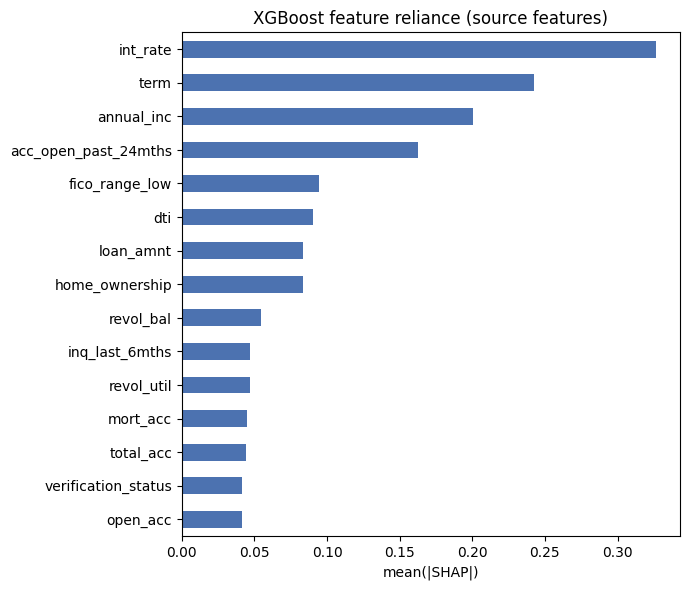

Saved 04_feature_importance.csv


,mean_abs_shap,rank
int_rate,0.326636,1
term,0.242451,2
annual_inc,0.200518,3
acc_open_past_24mths,0.162731,4
fico_range_low,0.094206,5
dti,0.090672,6
loan_amnt,0.083813,7
home_ownership,0.083537,8
revol_bal,0.054836,9
inq_last_6mths,0.047313,10


In [5]:
# Aggregate mean(|SHAP|) from one-hot columns back onto the 30 source features,
# mirroring llm_utils.top_xgb_features (longest-prefix wins).
mean_abs = np.abs(sv.values).mean(axis=0)
agg = {f: 0.0 for f in LLM_FEATURES}
for col, w in zip(feature_cols, mean_abs):
    if col in agg:
        agg[col] += float(w); continue
    cands = [f for f in LLM_FEATURES if col.startswith(f + '_')]
    if cands:
        agg[max(cands, key=len)] += float(w)

xgb_imp = (pd.Series(agg).sort_values(ascending=False)
           .rename('mean_abs_shap').to_frame())
xgb_imp['rank'] = range(1, len(xgb_imp) + 1)

fig, ax = plt.subplots(figsize=(7, 6))
xgb_imp['mean_abs_shap'].head(15)[::-1].plot.barh(ax=ax, color='#4C72B0')
ax.set_xlabel('mean(|SHAP|)'); ax.set_title('XGBoost feature reliance (source features)')
plt.tight_layout(); plt.show()

# Persist for the ML<->LLM overlay in 01g.
out = xgb_imp.reset_index().rename(columns={'index': 'feature'})
out.to_csv(f'{RESULTS_ML}/04_feature_importance.csv', index=False)
print('Saved 04_feature_importance.csv'); display(xgb_imp.head(10))


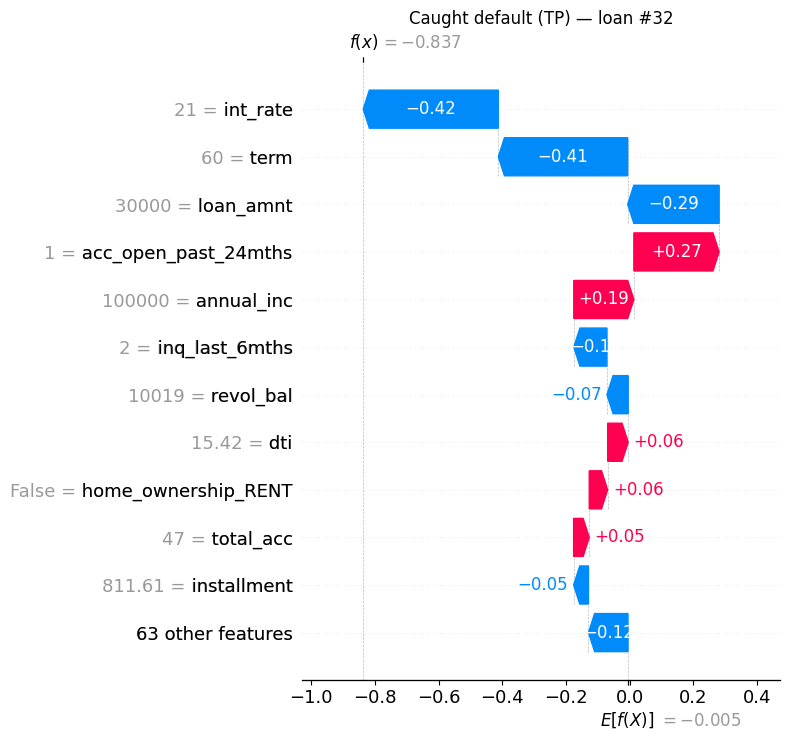

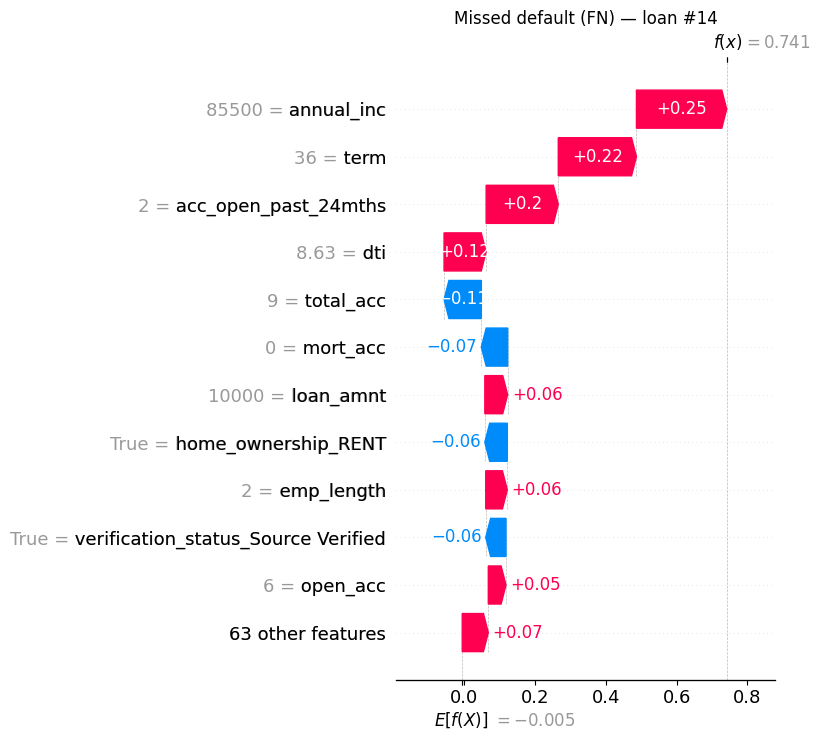

In [6]:
# Local explanations: one correctly-caught default and one missed default.
miss_default = np.where((y_true == 0) & (preds == 1))[0]   # FN: said paid, actually CO
caught_default = np.where((y_true == 0) & (preds == 0))[0]  # TP

for label, idxs in [('Caught default (TP)', caught_default), ('Missed default (FN)', miss_default)]:
    if len(idxs) == 0:
        print(f'No {label} cases.'); continue
    i = int(idxs[0])
    shap.plots.waterfall(sv[i], max_display=12, show=False)
    plt.title(f'{label} — loan #{i}'); plt.tight_layout(); plt.show()


## Part 4 — Feature Reliance (permutation cross-check)

SHAP is the primary reliance measure. We corroborate the ranking with
**permutation importance** (AUC drop when a feature is shuffled) on the real model —
a different method that should broadly agree if the SHAP ranking is robust.

In [7]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(model, X_scaled, y_true, scoring='roc_auc',
                            n_repeats=20, random_state=42)
agg_pi = {f: 0.0 for f in LLM_FEATURES}
for col, w in zip(feature_cols, pi.importances_mean):
    if col in agg_pi:
        agg_pi[col] += float(w); continue
    cands = [f for f in LLM_FEATURES if col.startswith(f + '_')]
    if cands:
        agg_pi[max(cands, key=len)] += float(w)

cmp = xgb_imp[['rank']].rename(columns={'rank': 'shap_rank'}).copy()
cmp['perm_importance'] = pd.Series(agg_pi)
cmp['perm_rank'] = cmp['perm_importance'].rank(ascending=False).astype(int)
print('SHAP vs permutation ranking (top 12 by SHAP):')
display(cmp.sort_values('shap_rank').head(12).round(4))


SHAP vs permutation ranking (top 12 by SHAP):


,shap_rank,perm_importance,perm_rank
int_rate,1,0.0244,2
term,2,0.0120,7
annual_inc,3,0.0227,3
acc_open_past_24mths,4,0.0042,14
fico_range_low,5,0.0249,1
dti,6,0.0198,4
loan_amnt,7,0.0062,12
home_ownership,8,0.0102,9
revol_bal,9,-0.0029,29
inq_last_6mths,10,-0.0025,28


## Part 5 — Error Analysis

Where the model fails, and at what cost. Missed defaults (FN) carry credit loss;
false rejections (FP) carry foregone profit. We slice errors by **grade** and
**FICO band** to see if failures concentrate in a segment. Cost constants match the
`01f` portfolio ledger (LGD €5,000 / missed default; €2,000 / false rejection).

In [8]:
err = sample.copy()
err['y_true'] = y_true; err['pred'] = preds; err['prob_fully_paid'] = probs
err['outcome'] = np.select(
    [(err.y_true == 0) & (err.pred == 0), (err.y_true == 0) & (err.pred == 1),
     (err.y_true == 1) & (err.pred == 0), (err.y_true == 1) & (err.pred == 1)],
    ['TP (caught default)', 'FN (missed default)', 'FP (false rejection)', 'TN (good approved)'],
    default='?')

LGD_COST, FP_COST = 5000, 2000
n_fn = (err.outcome == 'FN (missed default)').sum()
n_fp = (err.outcome == 'FP (false rejection)').sum()
print(f'Missed defaults (FN): {n_fn}  -> credit loss  ~ EUR {n_fn*LGD_COST:,}')
print(f'False rejections (FP): {n_fp}  -> lost profit  ~ EUR {n_fp*FP_COST:,}')
print(f'Approx. error cost on {len(err)} loans: EUR {n_fn*LGD_COST + n_fp*FP_COST:,}\n')

print('Errors by grade:')
display(pd.crosstab(err['grade'], err['outcome']))

err['fico_band'] = pd.cut(err['fico_range_low'], [0, 660, 700, 740, 850],
                          labels=['<660', '660-700', '700-740', '740+'])
print('Errors by FICO band:')
display(pd.crosstab(err['fico_band'], err['outcome']))


Missed defaults (FN): 8  -> credit loss  ~ EUR 40,000
False rejections (FP): 27  -> lost profit  ~ EUR 54,000
Approx. error cost on 100 loans: EUR 94,000

Errors by grade:


outcome,FN (missed default),FP (false rejection),TN (good approved),TP (caught default)
grade,,,,
A,0,0,14,0
B,7,1,30,1
C,1,9,12,1
D,0,10,2,2
E,0,6,0,3
F,0,1,0,0


Errors by FICO band:


outcome,FN (missed default),FP (false rejection),TN (good approved),TP (caught default)
fico_band,,,,
<660,0,6,3,1
660-700,8,15,30,5
700-740,0,5,15,1
740+,0,1,10,0


## Takeaways

- Performance, calibration, SHAP, feature reliance and error breakdown are now on
  record for the XGBoost baseline — the structured mirror of the LLM analyses.
- `04_feature_importance.csv` is consumed by `01g` for the ML-vs-LLM feature-reliance
  overlay.
- Read alongside `01g` (GPT-5.4) and `02d` (prompt variants) for the side-by-side.